In [2]:
!pip install torch scikit-learn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


--- Starting Deep Learning Training Loop ---
Epoch:  20 | Training Loss: 0.4475 | Test Accuracy: 78.0%
Epoch:  40 | Training Loss: 0.2778 | Test Accuracy: 88.0%
Epoch:  60 | Training Loss: 0.2242 | Test Accuracy: 89.0%
Epoch:  80 | Training Loss: 0.1879 | Test Accuracy: 90.5%
Epoch: 100 | Training Loss: 0.1367 | Test Accuracy: 93.5%
Epoch: 120 | Training Loss: 0.0835 | Test Accuracy: 97.5%
Epoch: 140 | Training Loss: 0.0492 | Test Accuracy: 97.5%
Epoch: 160 | Training Loss: 0.0322 | Test Accuracy: 98.5%
Epoch: 180 | Training Loss: 0.0232 | Test Accuracy: 99.0%
Epoch: 200 | Training Loss: 0.0184 | Test Accuracy: 99.0%

Training complete! Plotting decision boundary map...


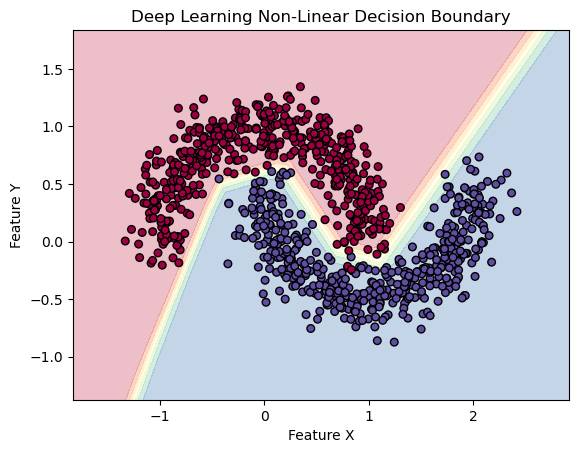

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# ==========================================
# 1. GENERATE SYNTHETIC DATA
# ==========================================
# Create 1,000 data points forming two interlocking half-circles
X_raw, y_raw = make_moons(n_samples=1000, noise=0.15, random_state=42)

# Convert raw NumPy arrays into PyTorch Float Tensors
X = torch.tensor(X_raw, dtype=torch.float32)
y = torch.tensor(y_raw, dtype=torch.float32).unsqueeze(1) # Reshape to (1000, 1)

# Split into Training (80%) and Test (20%) sets
train_split = int(0.8 * len(X))
X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]

# ==========================================
# 2. DEFINE THE DEEP NEURAL NETWORK
# ==========================================
class DeepNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1: Input (2 coordinates) -> Hidden Layer 1 (16 neurons)
        self.layer1 = nn.Linear(2, 16)
        # Layer 2: Hidden Layer 1 -> Hidden Layer 2 (8 neurons)
        self.layer2 = nn.Linear(16, 8)
        # Layer 3: Hidden Layer 2 -> Output (1 probability score)
        self.layer3 = nn.Linear(8, 1)
        
        # Non-linear activation function
        self.relu = nn.ReLU()
        # Sigmoid squashes output value strictly between 0 and 1
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pass input data through the network layers sequentially
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.layer3(x))
        return x

# Instantiate the model architecture
model = DeepNeuralNetwork()

# Define the Loss Function (Binary Cross Entropy for 0/1 classification)
criterion = nn.BCELoss()

# Define the Optimizer (Adam changes the neural weights based on gradients)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==========================================
# 3. THE TRAINING ENGINE LOOP
# ==========================================
epochs = 200
print("--- Starting Deep Learning Training Loop ---")

for epoch in range(1, epochs + 1):
    model.train()
    
    # 1. Forward Pass: compute predicted values
    predictions = model(X_train)
    
    # 2. Compute the Error (Loss)
    loss = criterion(predictions, y_train)
    
    # 3. Backward Pass: clear old memory, calculate gradients, adjust weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Evaluate performance every 20 training steps
    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test)
            # Round probabilities to absolute 0 or 1 boundaries
            test_preds_rounded = torch.round(test_preds)
            accuracy = (test_preds_rounded == y_test).sum().item() / len(y_test)
        
        print(f"Epoch: {epoch:3d} | Training Loss: {loss.item():.4f} | Test Accuracy: {accuracy * 100:.1f}%")

# ==========================================
# 4. VISUALIZE THE TRAINED DECISION BOUNDARY
# ==========================================
print("\nTraining complete! Plotting decision boundary map...")
model.eval()

# Generate a dense meshgrid matrix to plot the model's spatial boundary line
import numpy as np
x_min, x_max = X_raw[:, 0].min() - 0.5, X_raw[:, 0].max() + 0.5
y_min, y_max = X_raw[:, 1].min() - 0.5, X_raw[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = model(grid_tensor).reshape(xx.shape).numpy()

# Draw the background colors matching model predictions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Spectral)
# Scatter the actual real data points on top
plt.scatter(X_raw[:, 0], X_raw[:, 1], c=y_raw, s=30, cmap=plt.cm.Spectral, edgecolors='k')
plt.title("Deep Learning Non-Linear Decision Boundary")
plt.xlabel("Feature X")
plt.ylabel("Feature Y")
plt.show()